<a href="https://colab.research.google.com/github/mafe1307/analisis-datos-fac-equipo-4/blob/main/Trabajo_definitivo_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ==========================
# 1) Análisis de datos faltantes
# ==========================
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re, unicodedata
# Leer los datos
DATA_PATH = Path("/content/JEFAB_2024_final_noNR_imputed_PCA.xlsx")  # evita rutas de Colab
FIG_DIR = Path("figuras"); FIG_DIR.mkdir(exist_ok=True, parents=True)
TAB_DIR = Path("tablas");  TAB_DIR.mkdir(exist_ok=True, parents=True)

# --- Carga de datos ---
if not DATA_PATH.exists():
    raise SystemExit(f"No se encontró el archivo: {DATA_PATH}. Colócalo en '/content/'.")
df = pd.read_excel(DATA_PATH)

In [7]:
# demografia_robusta.py — Estudio Demográfico Extendido FAC

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re, unicodedata

# ==========================
# Configuración de rutas
# ==========================
DATA_PATH = Path("/content/JEFAB_2024_final_noNR_imputed_PCA.xlsx")
FIG_DIR = Path("figuras"); FIG_DIR.mkdir(exist_ok=True, parents=True)
TAB_DIR = Path("tablas");  TAB_DIR.mkdir(exist_ok=True, parents=True)

# ==========================
# Funciones auxiliares
# ==========================
def _norm(s):
    s = str(s) if s is not None else ""
    s = unicodedata.normalize("NFKD", s).encode("ascii","ignore").decode("ascii")
    return re.sub(r"\s+"," ", s).strip().upper()

def find_col(df, candidates):
    cand = [_norm(c) for c in candidates]
    norm_map = {c: _norm(c) for c in df.columns}
    for orig, normd in norm_map.items():
        if normd in cand:
            return orig
    for orig, normd in norm_map.items():
        if any(tok in normd for tok in cand):
            return orig
    return None

# ==========================
# Carga de datos
# ==========================
if not DATA_PATH.exists():
    raise SystemExit(f"No se encontró el archivo: {DATA_PATH}")
df = pd.read_excel(DATA_PATH).dropna(axis=1, how="all")

# Detectar columnas clave
col_edad   = find_col(df, ["EDAD2","EDAD"])
col_genero = find_col(df, ["GENERO","SEXO"])
col_grado  = find_col(df, ["GRADO","GRADO_MILITAR"])
col_educ   = find_col(df, ["NIVEL_EDUCATIVO","EDUCACION","ESCOLARIDAD"])
col_ingresos = find_col(df, ["INGRESO","SALARIO","SUELDO"])  # puede ser None

# ==========================
# 1) ANÁLISIS DE EDAD
# ==========================
if col_edad:
    s_edad = pd.to_numeric(df[col_edad], errors="coerce").dropna()
    fig_path = FIG_DIR / "A_demografia_edades_hist.png"
    plt.figure(figsize=(10,6))
    plt.hist(s_edad, bins=15, edgecolor='black')
    plt.title("Distribución de Edades", loc='left')
    plt.xlabel("Edad (años)"); plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150); plt.close()

# ==========================
# 2) ANÁLISIS DE GÉNERO
# ==========================
if col_genero:
    conteo_genero = df[col_genero].value_counts(dropna=False)
    plt.figure(figsize=(7,5))
    ax = conteo_genero.plot(kind='bar', edgecolor='black')
    ax.set_title('Distribución por Género')
    plt.tight_layout()
    plt.savefig(FIG_DIR / "A_demografia_genero_bar.png", dpi=150)
    plt.close()

# ==========================
# 3) GRADO MILITAR en HISTOGRAMA
# ==========================
if col_grado:
    grados = df[col_grado].astype(str).str.strip()
    conteo_grados = grados.value_counts()
    plt.figure(figsize=(12,6))
    conteo_grados.plot(kind="bar", edgecolor="black")
    plt.title("Distribución de Grados Militares")
    plt.ylabel("Frecuencia"); plt.xlabel("Grado Militar")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "A_grado_militar_hist.png", dpi=150)
    plt.close()

# ==========================
# 4) ROBUSTECIENDO EL ANÁLISIS
# ==========================

# --- 4.1 Matriz de correlación numérica ---
df_num = df.select_dtypes(include=[np.number])
corr_matrix = df_num.corr()
corr_matrix.to_csv(TAB_DIR / "B_correlacion_numerica.csv")

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación Numérica")
plt.tight_layout()
plt.savefig(FIG_DIR / "B_correlacion_heatmap.png", dpi=150)
plt.close()

# --- 4.2 Selección de variables con |r| > 0.3 ---
strong_corrs = []
threshold = 0.3
for c1 in corr_matrix.columns:
    for c2 in corr_matrix.columns:
        if c1 != c2:
            r = corr_matrix.loc[c1, c2]
            if abs(r) >= threshold:
                strong_corrs.append((c1, c2, r))
pd.DataFrame(strong_corrs, columns=["Var1","Var2","r"]).to_csv(TAB_DIR / "B_correlaciones_fuertes.csv", index=False)

# --- 4.3 Heatmap: Grado Militar × Género ---
if col_grado and col_genero:
    tabla = pd.crosstab(df[col_grado], df[col_genero], normalize="index")*100
    plt.figure(figsize=(10,6))
    sns.heatmap(tabla, annot=True, fmt=".1f", cmap="Blues")
    plt.title("Distribución de género por grado militar (%)")
    plt.ylabel("Grado militar"); plt.xlabel("Género")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "B_grado_genero_heatmap.png", dpi=150)
    plt.close()

# --- 4.4 Heatmap alternativo: Edad × Estrato con promedio de grado militar ---
col_estrato = find_col(df, ["ESTRATO"])
if col_edad and col_grado and col_estrato:
    df["EDAD_BIN"] = pd.to_numeric(df[col_edad], errors="coerce")
    df["EDAD_BIN"] = pd.cut(df["EDAD_BIN"], bins=range(15, 70, 5))

    tabla_heat = pd.pivot_table(
        df,
        index="EDAD_BIN",
        columns=col_estrato,
        values=col_grado,
        aggfunc="count"
    )

    plt.figure(figsize=(10,6))
    sns.heatmap(tabla_heat, annot=True, fmt="d", cmap="YlOrBr")
    plt.title("Frecuencia de personas según edad y estrato")
    plt.ylabel("Edad (rangos)")
    plt.xlabel("Estrato")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "B_heatmap_edad_estrato.png", dpi=150)
    plt.close()

# --- 4.5 Facet grid: Educación × Género con percepción servicios ---
proxy_serv = find_col(df, ["SERV_EDU_CAL_SERV","SERV_EDU_RESULT_ACAD"])
if col_educ and col_genero and proxy_serv:
    g = sns.catplot(data=df, x=col_educ, y=proxy_serv, hue=col_genero,
                    kind="bar", height=6, aspect=1.5)
    g.set_xticklabels(rotation=45)
    g.fig.suptitle("Percepción de servicios educativos por educación y género", y=1.02)
    plt.tight_layout()
    g.savefig(FIG_DIR / "B_facet_educ_genero_servicios.png", dpi=150)
    plt.close()

print("\n=== ANÁLISIS DEMOGRÁFICO ROBUSTO COMPLETADO ===")
print(f"- Figuras guardadas en {FIG_DIR}")
print(f"- Tablas guardadas en {TAB_DIR}")

/tmp/ipython-input-3201371264.py:134: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla_heat = pd.pivot_table(



=== ANÁLISIS DEMOGRÁFICO ROBUSTO COMPLETADO ===
- Figuras guardadas en figuras
- Tablas guardadas en tablas


=== ANÁLISIS FAMILIAR (Estudiante B) ===

=== ESTADO CIVIL ===
ESTADO_CIVIL
CASADO        3889
SOLTERO/A     2084
DIVORCIADO     250
SEPARADO       161
VIUDO/A         39
Name: count, dtype: int64
% de casados: 60.55%


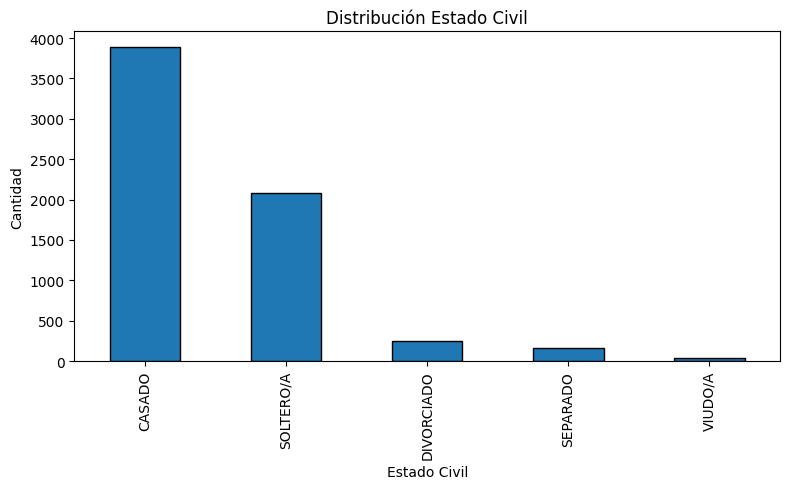

In [8]:
# ==========================
# ANÁLISIS FAMILIAR
# ==========================
# --- Detectar columnas clave ---
col_estado   = find_col(df, ["ESTADO_CIVIL"])
col_hijos    = find_col(df, ["HIJOS"])
col_numhijos = find_col(df, ["NUMERO_HIJOS"])
col_conv     = find_col(df, ["HABITA_VIVIENDA_FAMILIAR","CONVIVE_CON_FAMILIA"])
col_edad     = find_col(df, ["EDAD2","EDAD"])
col_genero   = find_col(df, ["GENERO","SEXO"])
col_edu      = find_col(df, ["NIVEL_EDUCATIVO"])
col_estrato  = find_col(df, ["ESTRATO"])
col_vivienda = find_col(df, ["VIVIENDA_PROPIA"])

print("=== ANÁLISIS FAMILIAR (Estudiante B) ===")

# ==========================
# 1) Estado civil
# ==========================
print("\n=== ESTADO CIVIL ===")
if col_estado:
    conteo_ec = df[col_estado].value_counts(dropna=False)
    print(conteo_ec)
    porc_casados = (conteo_ec.get("CASADO",0)/len(df)*100) if len(df)>0 else 0
    print(f"% de casados: {porc_casados:.2f}%")

    plt.figure(figsize=(8,5))
    conteo_ec.plot(kind="bar", edgecolor="black")
    plt.title("Distribución Estado Civil")
    plt.xlabel("Estado Civil"); plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "B_estado_civil_bar.png", dpi=130)
    plt.show(); plt.close()
else:
    print("No se encontró columna de estado civil.")


=== HIJOS ===
HIJOS
SI    3669
NO    2754
Name: count, dtype: int64


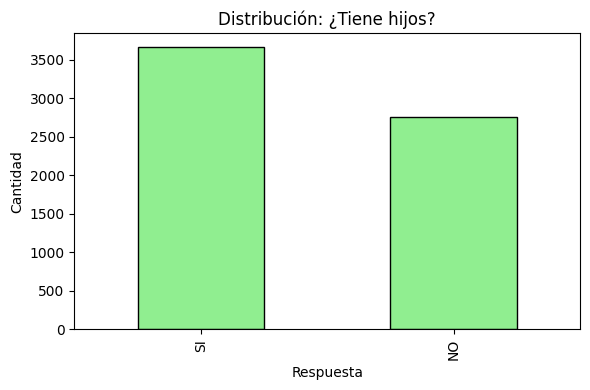


Número de hijos - estadísticos:
count    6423.000000
mean        1.871244
std         0.597216
min         1.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         5.000000
Name: NUMERO_HIJOS, dtype: float64


In [9]:
# ==========================
# 2) Hijos
# ==========================
print("\n=== HIJOS ===")
if col_hijos:
    conteo_h = df[col_hijos].value_counts(dropna=False)
    print(conteo_h)

    plt.figure(figsize=(6,4))
    conteo_h.plot(kind="bar", edgecolor="black", color="lightgreen")
    plt.title("Distribución: ¿Tiene hijos?")
    plt.xlabel("Respuesta"); plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "B_hijos_bar.png", dpi=130)
    plt.show(); plt.close()

if col_numhijos:
    serie_h = pd.to_numeric(df[col_numhijos], errors="coerce").dropna()
    print("\nNúmero de hijos - estadísticos:")
    print(serie_h.describe())
    serie_h.to_csv(TAB_DIR / "B_numero_hijos.csv", index=False)



=== CONVIVENCIA ===
HABITA_VIVIENDA_FAMILIAR
NO    5238
SI    1185
Name: count, dtype: int64


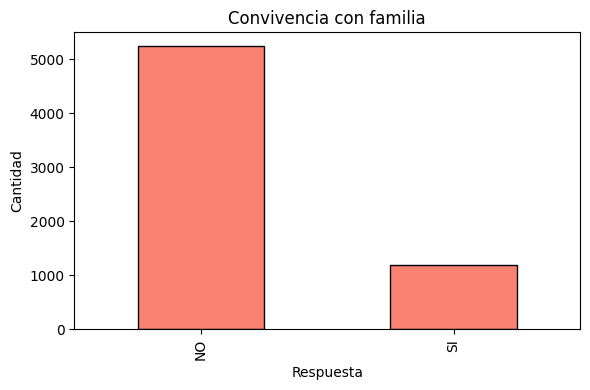

In [10]:
# ==========================
# 3) Convivencia familiar
# ==========================
print("\n=== CONVIVENCIA ===")
if col_conv:
    conteo_conv = df[col_conv].value_counts(dropna=False)
    print(conteo_conv)

    plt.figure(figsize=(6,4))
    conteo_conv.plot(kind="bar", edgecolor="black", color="salmon")
    plt.title("Convivencia con familia")
    plt.xlabel("Respuesta"); plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "B_convivencia_bar.png", dpi=130)
    plt.show(); plt.close()



=== PATRONES FAMILIARES ===

% Hijos según Estado Civil:
HIJOS           NO    SI
ESTADO_CIVIL            
CASADO        23.1  76.9
DIVORCIADO    22.4  77.6
SEPARADO      11.8  88.2
SOLTERO/A     85.3  14.7
VIUDO/A        7.7  92.3

% Convivencia según Hijos:
HABITA_VIVIENDA_FAMILIAR    NO    SI
HIJOS                               
NO                        76.9  23.1
SI                        85.0  15.0

Edad promedio por estado civil:
ESTADO_CIVIL
CASADO        39.7
DIVORCIADO    40.4
SEPARADO      40.9
SOLTERO/A     30.2
VIUDO/A       47.6
Name: EDAD2, dtype: float64


<Figure size 900x600 with 0 Axes>

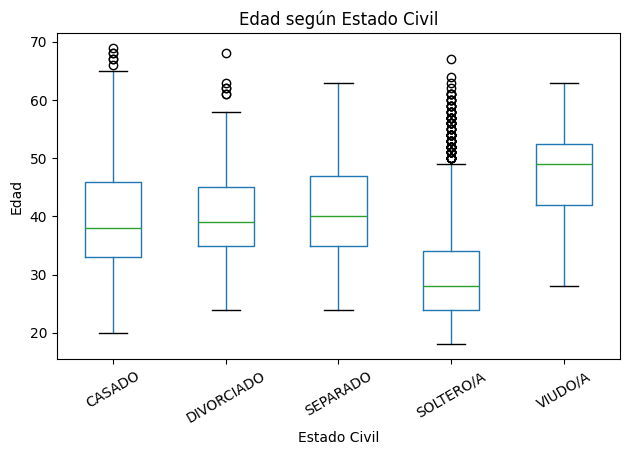


% Hijos según Género:
HIJOS     NO    SI
SEXO              
HOMBRE  43.7  56.3
MUJER   41.0  59.0

% Hijos según Nivel Educativo:
HIJOS              NO    SI
NIVEL_EDUCATIVO            
BÁSICA            3.0  97.0
DOCTORADO        53.3  46.7
ESPECIALIZACIN   41.6  58.4
MAESTRÍA         41.3  58.7
MEDIA            19.7  80.3
PROFESIONAL      55.5  44.5
TCNICO           30.1  69.9
TECNOLGICO       46.9  53.1


In [11]:
# ==========================
# 4) Patrones cruzados
# ==========================
print("\n=== PATRONES FAMILIARES ===")

# Estado civil vs Hijos
if col_estado and col_hijos:
    ct_ec_h = pd.crosstab(df[col_estado], df[col_hijos], normalize="index")*100
    print("\n% Hijos según Estado Civil:")
    print(ct_ec_h.round(1))
    ct_ec_h.to_csv(TAB_DIR / "B_estado_vs_hijos.csv")

# Hijos vs Convivencia
if col_hijos and col_conv:
    ct_h_c = pd.crosstab(df[col_hijos], df[col_conv], normalize="index")*100
    print("\n% Convivencia según Hijos:")
    print(ct_h_c.round(1))
    ct_h_c.to_csv(TAB_DIR / "B_hijos_vs_convivencia.csv")

# Edad y estado civil
if col_edad and col_estado:
    serie_edad = pd.to_numeric(df[col_edad], errors="coerce")
    resumen = df.groupby(col_estado)[col_edad].mean().round(1)
    print("\nEdad promedio por estado civil:")
    print(resumen)
    resumen.to_csv(TAB_DIR / "B_edad_vs_estado.csv")
# --- Boxplot: Edad ~ Estado civil (corregido) ---
if col_edad and col_estado:
    # Copia segura y tipos correctos
    _tmp = df[[col_edad, col_estado]].copy()
    _tmp[col_edad] = pd.to_numeric(_tmp[col_edad], errors="coerce")
    _tmp = _tmp.dropna(subset=[col_edad, col_estado])

    if not _tmp.empty:
        plt.figure(figsize=(9,6))
        # Usar las referencias de columna reales (no strings literales)
        _tmp.boxplot(column=col_edad, by=col_estado, grid=False)
        plt.title("Edad según Estado Civil")
        plt.suptitle("")  # quita el título automático de pandas
        plt.ylabel("Edad")
        plt.xlabel("Estado Civil")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.savefig(FIG_DIR / "B_edad_estado_civil.png", dpi=130)
        plt.show(); plt.close()
    else:
        print("No hay datos válidos para el boxplot de edad por estado civil.")

# Género y familia
if col_genero and col_hijos:
    ct_g_h = pd.crosstab(df[col_genero], df[col_hijos], normalize="index")*100
    print("\n% Hijos según Género:")
    print(ct_g_h.round(1))
    ct_g_h.to_csv(TAB_DIR / "B_genero_vs_hijos.csv")

# Educación y familia
if col_edu and col_hijos:
    ct_e_h = pd.crosstab(df[col_edu], df[col_hijos], normalize="index")*100
    print("\n% Hijos según Nivel Educativo:")
    print(ct_e_h.round(1))
    ct_e_h.to_csv(TAB_DIR / "B_educacion_vs_hijos.csv")



% Hijos según Estrato Socioeconómico:
HIJOS      NO    SI
ESTRATO            
1        38.1  61.9
2        47.4  52.6
3        41.1  58.9
4        44.4  55.6
5        37.3  62.7
6        57.7  42.3


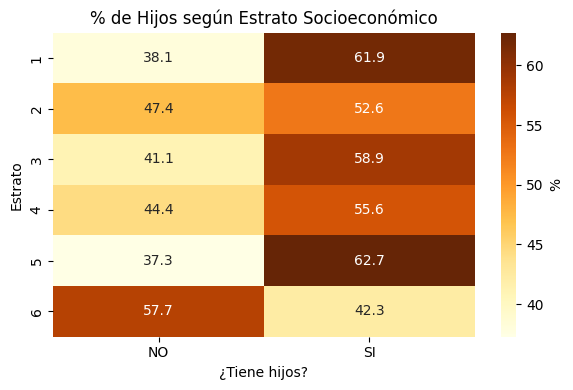


Estado Civil según Estrato:
ESTADO_CIVIL  CASADO  DIVORCIADO  SEPARADO  SOLTERO/A  VIUDO/A
ESTRATO                                                       
1               52.3         3.0       3.0       40.1      1.5
2               53.7         2.8       1.9       41.3      0.3
3               62.9         4.6       2.7       29.2      0.6
4               66.0         3.2       2.7       27.3      0.8
5               75.5         3.6       1.8       18.2      0.9
6               61.5        11.5       0.0       26.9      0.0


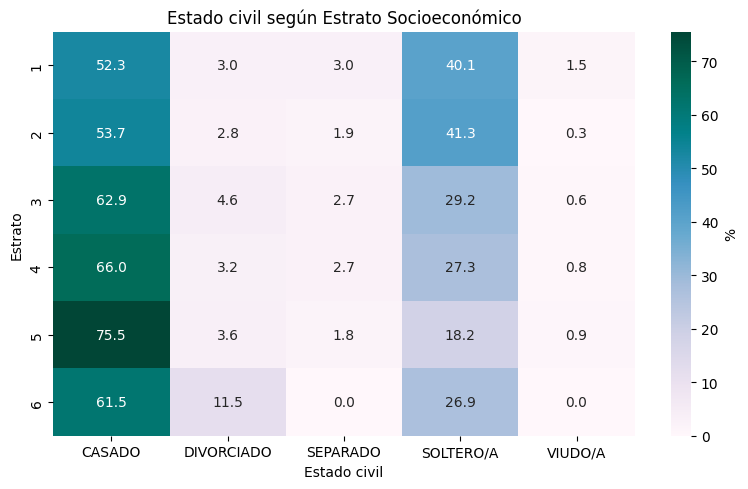

In [12]:
# Estrato vs Hijos
if col_estrato and col_hijos:
    ct_es_h = pd.crosstab(df[col_estrato], df[col_hijos], normalize="index")*100
    print("\n% Hijos según Estrato Socioeconómico:")
    print(ct_es_h.round(1))
    ct_es_h.to_csv(TAB_DIR / "B_estrato_vs_hijos.csv")

import matplotlib.pyplot as plt
import seaborn as sns

if col_estrato and col_hijos:
    ct_es_h = pd.crosstab(df[col_estrato], df[col_hijos], normalize="index")*100

    plt.figure(figsize=(6,4))
    sns.heatmap(ct_es_h, annot=True, fmt=".1f", cmap="YlOrBr", cbar_kws={"label": "%"})
    plt.title("% de Hijos según Estrato Socioeconómico")
    plt.xlabel("¿Tiene hijos?")
    plt.ylabel("Estrato")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "B_heatmap_estrato_hijos.png", dpi=130)
    plt.show()


# Estrato vs Estado civil
if col_estrato and col_estado:
    ct_es_ec = pd.crosstab(df[col_estrato], df[col_estado], normalize="index")*100
    print("\nEstado Civil según Estrato:")
    print(ct_es_ec.round(1))
    ct_es_ec.to_csv(TAB_DIR / "B_estrato_vs_estado.csv")
if col_estrato and col_estado:
    ct_es_ec = pd.crosstab(df[col_estrato], df[col_estado], normalize="index")*100

    plt.figure(figsize=(8,5))
    sns.heatmap(ct_es_ec, annot=True, fmt=".1f", cmap="PuBuGn", cbar_kws={"label": "%"})
    plt.title("Estado civil según Estrato Socioeconómico")
    plt.xlabel("Estado civil")
    plt.ylabel("Estrato")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "B_heatmap_estrato_estado.png", dpi=130)
    plt.show()



Estado Civil según Tenencia de Vivienda:
ESTADO_CIVIL     CASADO  DIVORCIADO  SEPARADO  SOLTERO/A  VIUDO/A
VIVIENDA_PROPIA                                                  
NO                 49.1         3.6       2.4       44.6      0.3
SI                 75.5         4.3       2.7       16.5      1.0


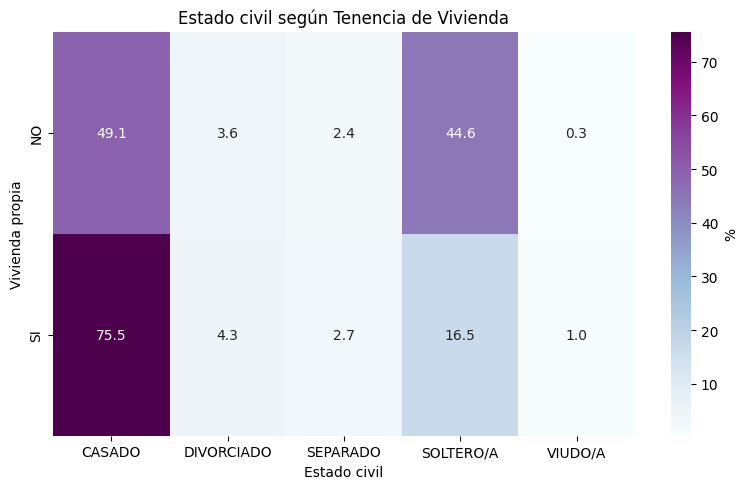


% Hijos según Vivienda Propia:
HIJOS              NO    SI
VIVIENDA_PROPIA            
NO               56.1  43.9
SI               25.5  74.5


In [13]:
# Vivienda propia vs Estado civil
if col_vivienda and col_estado:
    ct_v_ec = pd.crosstab(df[col_vivienda], df[col_estado], normalize="index")*100
    print("\nEstado Civil según Tenencia de Vivienda:")
    print(ct_v_ec.round(1))
    ct_v_ec.to_csv(TAB_DIR / "B_vivienda_vs_estado.csv")
import matplotlib.pyplot as plt
import seaborn as sns

if col_vivienda and col_estado:
    ct_v_ec = pd.crosstab(df[col_vivienda], df[col_estado], normalize="index")*100

    plt.figure(figsize=(8,5))
    sns.heatmap(ct_v_ec, annot=True, fmt=".1f", cmap="BuPu", cbar_kws={"label":"%"})
    plt.title("Estado civil según Tenencia de Vivienda")
    plt.xlabel("Estado civil")
    plt.ylabel("Vivienda propia")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "B_heatmap_vivienda_estado.png", dpi=130)
    plt.show()


# Vivienda propia vs Hijos
if col_vivienda and col_hijos:
    ct_v_h = pd.crosstab(df[col_vivienda], df[col_hijos], normalize="index")*100
    print("\n% Hijos según Vivienda Propia:")
    print(ct_v_h.round(1))
    ct_v_h.to_csv(TAB_DIR / "B_vivienda_vs_hijos.csv")


Género x Hijos x Convivencia (%):
HABITA_VIVIENDA_FAMILIAR    NO    SI
SEXO   HIJOS                        
HOMBRE NO                 79.0  21.0
       SI                 87.3  12.7
MUJER  NO                 71.8  28.2
       SI                 80.1  19.9


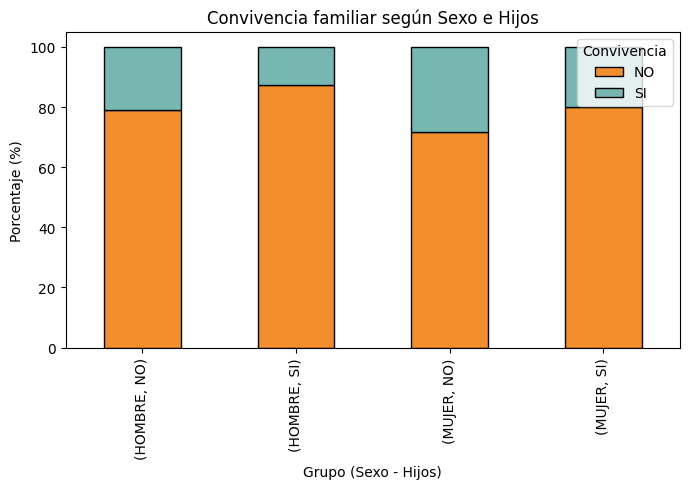

In [14]:
# Género x Hijos x Convivencia
if col_genero and col_hijos and col_conv:
    triple = pd.crosstab([df[col_genero], df[col_hijos]], df[col_conv], normalize="index")*100
    print("\nGénero x Hijos x Convivencia (%):")
    print(triple.round(1))
    triple.to_csv(TAB_DIR / "B_genero_hijos_convivencia.csv")
# Reorganizar para stacked bar a partir de triple
df_stacked = triple.reset_index().set_index(["SEXO","HIJOS"])[["NO","SI"]]

# Gráfico stacked
df_stacked.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5),
    color=["#f28e2b","#76b7b2"],
    edgecolor="black"
)
plt.title("Convivencia familiar según Sexo e Hijos")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Grupo (Sexo - Hijos)")
plt.legend(title="Convivencia")
plt.tight_layout()
plt.show()